# data
> Load MIR spectra and δ13C measurements of cassava leaves

This module reads the two raw files and aligns them into arrays ready for `soilspectfm` transforms and scikit-learn estimators. The data isn't part of the repo, so every loader takes the file location as an argument.

In [ ]:
#| default_exp data

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

In [ ]:
#| export
import numpy as np, pandas as pd
from fastcore.basics import AttrDict
from pathlib import Path

In [ ]:
from soilspectfm.all import *

## Spectra

In [ ]:
#| exports
def load_spectra(
    fname, # CSV with one row per wavenumber and one column per sample
):
    "Read MIR absorbance spectra as `(X, ws, ids)`, with one row of `X` per sample"
    df = pd.read_csv(fname, index_col=0)
    return df.values.T, df.index.values, df.columns.to_numpy(str)

The spectra file stores one wavenumber per row and one sample per column. scikit-learn expects one sample per row, so `load_spectra` transposes it. The wavenumbers `ws` (cm⁻¹, ascending) are returned separately, because `soilspectfm` transforms such as `Trim` and `Resample` take them as a parameter.

In [ ]:
#| eval: false
X, ws, ids = load_spectra('../data/specs_trim.csv')
test_eq(X.shape, (len(ids), len(ws)))
X.shape, ws[[0, -1]], ids[:3]

((1184, 1711),
 array([ 651.8218, 3949.5   ]),
 array(['1456_001', '1456_002', '1456_003'], dtype='<U31'))

## δ13C

In [ ]:
#| exports
def load_c13(
    fname, # CSV of sample ids and their δ13C (‰)
) -> pd.Series:
    "Read δ13C values as a `Series` indexed by sample id"
    return pd.read_csv(fname, index_col=0).iloc[:, 0].rename('c13')

In [ ]:
#| eval: false
c13 = load_c13('../data/all_batches_wet_chem.csv')
c13.describe()

count    1291.000000
mean      -26.917553
std         1.952382
min       -30.930046
25%       -28.440766
50%       -26.995435
75%       -25.793860
max       -21.227139
Name: c13, dtype: float64

## Batches

Sample ids have the form `<batch>_<sample>`. Each batch is a set of cassava plants grown under its own conditions and scanned at its own time, on the same spectrometer. Batch is the grouping variable for validation.

In [ ]:
#| exports
def batch_of(
    ids, # Sample ids of the form `<batch>_<sample>`
) -> np.ndarray:
    "Batch of each sample id"
    return np.array([o.split('_')[0] for o in ids])

In [ ]:
test_eq(batch_of(['1456_001', '1722_180']), ['1456', '1722'])

## Aligned dataset

In [ ]:
#| exports
def load_data(
    path='data', # Folder holding both files
    spectra='specs_trim.csv', # Spectra file name
    c13='all_batches_wet_chem.csv', # δ13C file name
) -> AttrDict:
    "Spectra and δ13C of the samples present in both files"
    path = Path(path)
    X, ws, ids = load_spectra(path/spectra)
    y = load_c13(path/c13)
    keep = np.isin(ids, y.index)
    return AttrDict(X=X[keep], ws=ws, y=y[ids[keep]].values, ids=ids[keep], batch=batch_of(ids[keep]))

`load_data` returns an `AttrDict` of numpy arrays. All of them are aligned by sample, except `ws`, which has one entry per wavenumber:

- `X`: absorbance, one row per sample
- `ws`: wavenumbers (cm⁻¹, ascending)
- `y`: δ13C (‰)
- `ids`: sample ids
- `batch`: batch of each sample

Only samples with both a spectrum and a δ13C value are kept: 26 spectra have no δ13C value, and 133 δ13C values have no spectrum.

In [ ]:
#| eval: false
d = load_data('../data')
test_eq(d.y, c13[d.ids].values)
d.X.shape, len(np.setdiff1d(ids, d.ids)), len(np.setdiff1d(c13.index, d.ids))

((1158, 1711), 26, 133)

Samples per batch:

In [ ]:
#| eval: false
pd.Series(d.batch).value_counts().sort_index()

1456    149
1586    168
1592    244
1597     97
1678    144
1722    177
1723    179
Name: count, dtype: int64

A random sample of the spectra:

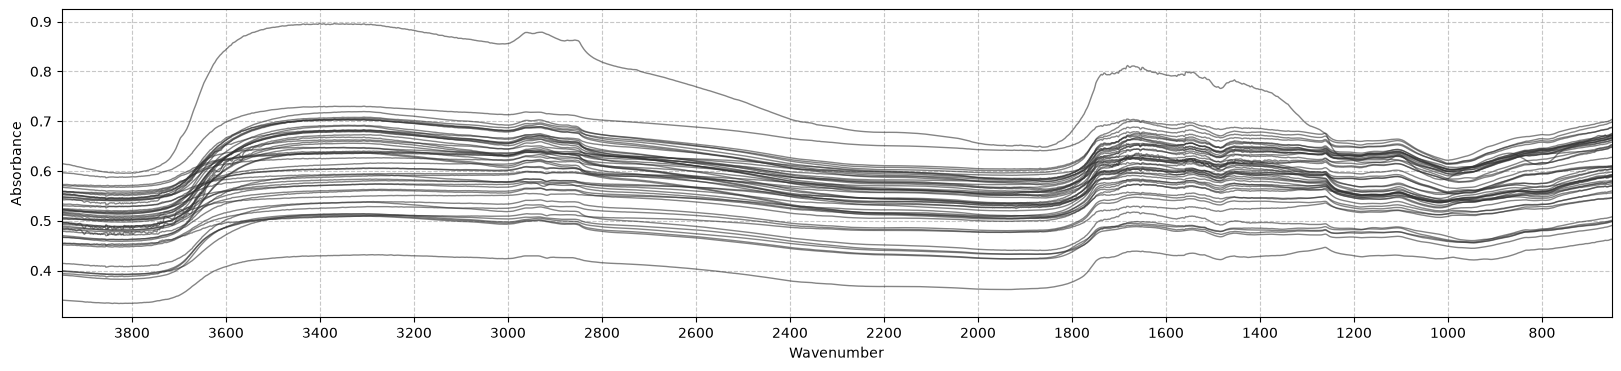

In [ ]:
#| eval: false
plot_spectra(d.X, d.ws, sample=50, ascending=False);

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()